<a href="https://colab.research.google.com/github/karthik-garlapally/Machine_Learning/blob/main/Assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 7

###Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

###Load the Iris Dataset

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)

print("First 5 records:")
print(df.head(8))

First 5 records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
5                5.4               3.9                1.7               0.4
6                4.6               3.4                1.4               0.3
7                5.0               3.4                1.5               0.2


###Standardize the Feature Values

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Standardized data:")
print(X_scaled[:5])

Standardized data:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


###Perform Hierarchical Clustering

In [ ]:
Z = linkage(
    X_scaled,
    method='centroid',
    metric='euclidean'
)

###Generate the Dendrogram

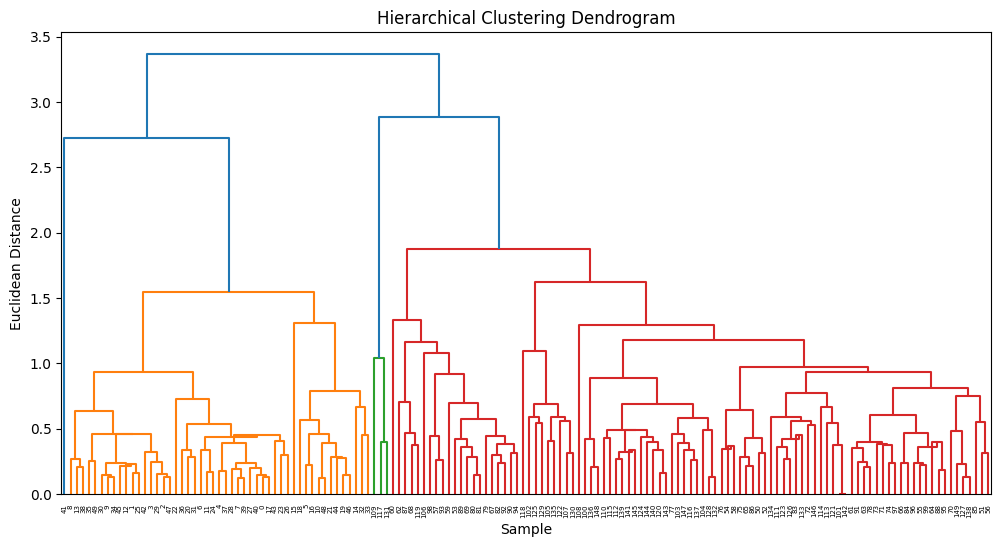

In [ ]:
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample")
plt.ylabel("Euclidean Distance")
plt.show()

###Cut the Hierarchy into 3 Clusters

In [ ]:
clusters = fcluster(
    Z,
    t=3,
    criterion='maxclust'
)
clusters = clusters - 1
print("Cluster labels:")
print(clusters)

Cluster labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2
 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


###Display Cluster Assigned to Each Sample

In [ ]:
df["Cluster"] = clusters
print("Cluster assigned to each sample:")
print(df[["Cluster"]].to_string())

Cluster assigned to each sample:
     Cluster
0          0
1          0
2          0
3          0
4          0
5          0
6          0
7          0
8          0
9          0
10         0
11         0
12         0
13         0
14         0
15         0
16         0
17         0
18         0
19         0
20         0
21         0
22         0
23         0
24         0
25         0
26         0
27         0
28         0
29         0
30         0
31         0
32         0
33         0
34         0
35         0
36         0
37         0
38         0
39         0
40         0
41         0
42         0
43         0
44         0
45         0
46         0
47         0
48         0
49         0
50         2
51         2
52         2
53         2
54         2
55         2
56         2
57         2
58         2
59         2
60         2
61         2
62         2
63         2
64         2
65         2
66         2
67         2
68         2
69         2
70         2
71         2
72         2
73   

###Count Samples in Each Cluster

In [ ]:
print("Number of samples in each cluster:")
print(df["Cluster"].value_counts().sort_index())

Number of samples in each cluster:
Cluster
0    50
1     3
2    97
Name: count, dtype: int64


###Visualize the Final Clusters

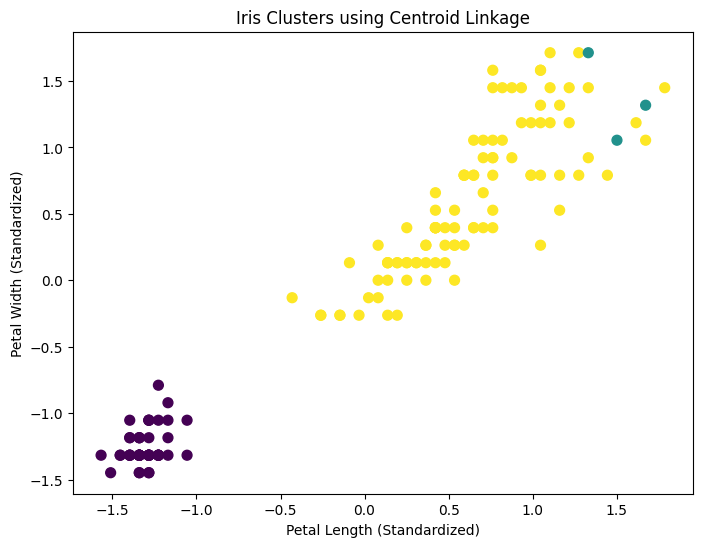

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=clusters,
    s=50
)
plt.xlabel("Petal Length (Standardized)")
plt.ylabel("Petal Width (Standardized)")
plt.title("Iris Clusters using Centroid Linkage")
plt.show()

###Compare Clusters with Actual Species

In [ ]:
comparison = pd.DataFrame({
    "Actual Species": iris.target_names[y],
    "Cluster": clusters
})
print("Comparison of Actual Species and Clusters:")
print(pd.crosstab(
        comparison["Actual Species"],
        comparison["Cluster"]
    ))

Comparison of Actual Species and Clusters:
Cluster          0  1   2
Actual Species           
setosa          50  0   0
versicolor       0  0  50
virginica        0  3  47


###Calculate Silhouette Score

In [ ]:
silhouette = silhouette_score(
    X_scaled,
    clusters
)
print("Silhouette Score:", silhouette)

Silhouette Score: 0.4802669329728697


###Calculate Adjusted Rand Index

In [ ]:
ari = adjusted_rand_score(
    y,
    clusters
)
print("Adjusted Rand Index:", ari)

Adjusted Rand Index: 0.5621364251426576


##Final conclusion

The program performs unsupervised hierarchical clustering on the Iris dataset. The four feature values are first standardized, then Centroid Linkage with Euclidean distance is used to construct the hierarchy. The dendrogram shows the merging process, and the hierarchy is cut into 3 clusters. The final clusters are visualized using Petal Length and Petal Width. The Silhouette Score evaluates the quality of the clusters, while Adjusted Rand Index compares the generated clusters with the actual Iris species